# RL-8 : Model-Based RL — Dyna-Q et planification

**Serie** : Reinforcement Learning | **Notebook** : 8/13 | **Duree estimee** : 45-50 min

**Prerequis** : notebook 5 (MDP, programmation dynamique, Q-Learning tabulaire).

## Objectifs pedagogiques

- Distinguer les approches **model-free** (Q-Learning, DQN, PPO) des approches **model-based** (Dyna, MCTS, MuZero)
- **Apprendre un modele du monde** a partir de l'experience reelle de l'agent
- Implementer **Dyna-Q** : entrelacer apprentissage direct et planification sur experience simulee
- Mesurer le gain en **efficacite d'echantillonnage** (sample efficiency) apporte par la planification
- Comprendre ce qui se passe quand **le modele se trompe** (environnement changeant) et comment **Dyna-Q+** y remedie
- Decouvrir la **planification au moment de la decision** (rollouts), porte d'entree vers MCTS et AlphaZero

## Plan

1. Model-free vs model-based : pourquoi un modele ?
2. Le labyrinthe de Sutton & Barto
3. Baseline model-free : Q-Learning direct
4. Apprendre un modele du monde
5. Dyna-Q : apprendre ET planifier
6. Quand le modele se trompe : Blocking Maze et Dyna-Q+
7. Planification au moment de la decision : des rollouts a MCTS
8. Exercices
9. Conclusion et passerelles

## 1. Model-free vs model-based : pourquoi un modele ?

Tous les algorithmes vus jusqu'ici dans cette serie (Q-Learning, DQN, REINFORCE, A2C, PPO, SAC)
sont **model-free** : ils apprennent une fonction de valeur ou une politique *directement* a partir
des transitions vecues, sans jamais chercher a representer **comment le monde fonctionne**.
Chaque amelioration de la politique exige donc de nouvelles interactions reelles avec l'environnement.

Un **modele** de l'environnement est tout ce qui permet a l'agent de *predire* la consequence d'une
action : a partir d'un etat $s$ et d'une action $a$, le modele fournit (une distribution sur)
l'etat suivant $s'$ et la recompense $r$. Avec un modele, l'agent peut generer de l'**experience
simulee** — gratuite — et s'en servir pour ameliorer sa fonction de valeur : c'est la **planification**.

| | Model-free | Model-based |
|---|---|---|
| Ce qui est appris | $Q(s,a)$ ou $\pi(a\|s)$ | $Q$ / $\pi$ **et** un modele $\hat{P}, \hat{R}$ |
| Cout par amelioration | experience **reelle** | experience reelle + calcul (simulation) |
| Efficacite d'echantillonnage | faible a moyenne | **elevee** |
| Risque principal | lenteur d'apprentissage | **biais du modele** (modele faux => politique fausse) |
| Exemples | Q-Learning, DQN, PPO, SAC | Dyna-Q, MCTS, AlphaZero, MuZero, World Models |

L'enjeu est crucial des que l'experience reelle est **chere ou risquee** : un bras robotique qui casse,
un patient, un portefeuille de trading. En robotique comme en finance, on prefere "rever" des milliers
de scenarios dans un simulateur appris plutot que de les payer dans le monde reel.

**L'architecture Dyna** (Sutton, 1990) est la maniere la plus simple d'unifier les deux mondes.
L'agent boucle sur trois activites :

1. **Agir** : interagir avec l'environnement reel (politique $\varepsilon$-greedy sur $Q$) ;
2. **Apprendre le modele** : memoriser les transitions observees $(s, a) \rightarrow (r, s')$ ;
3. **Planifier** : rejouer $n$ transitions *simulees* tirees du modele et mettre a jour $Q$
   avec exactement la meme regle que le Q-Learning.

La planification n'est donc rien d'autre que du Q-Learning sur experience imaginaire.

In [1]:
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

# Reproductibilite
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f"numpy {np.__version__}")
print("Pas de framework lourd ici : le model-based tabulaire tient en numpy pur.")

numpy 2.2.6
Pas de framework lourd ici : le model-based tabulaire tient en numpy pur.


## 2. Le labyrinthe de Sutton & Barto

Nous reprenons le **Dyna Maze** du chapitre 8 de *Reinforcement Learning: An Introduction*
(Sutton & Barto, 2e ed., figure 8.2) : une grille 6x9, un depart `S`, un but `G`, et quelques murs.

```
. . . . . . . # G        # = mur
. . # . . . . # .        S = depart (ligne 2, colonne 0)
S . # . . . . # .        G = but    (ligne 0, colonne 8)
. . # . . . . . .
. . . . . # . . .
. . . . . . . . .
```

Caracteristiques :

- **Actions** : haut, bas, gauche, droite. Se deplacer vers un mur ou hors de la grille laisse l'agent sur place.
- **Recompense** : $+1$ en atteignant `G` (fin d'episode), $0$ partout ailleurs — recompense **eparse**.
- **Facteur d'actualisation** : $\gamma = 0.95$, ce qui pousse l'agent a trouver le chemin le plus court
  (14 pas pour le chemin optimal).

L'environnement est **deterministe** : c'est le cadre ideal pour un premier modele appris
(une seule observation suffit a connaitre parfaitement une transition).

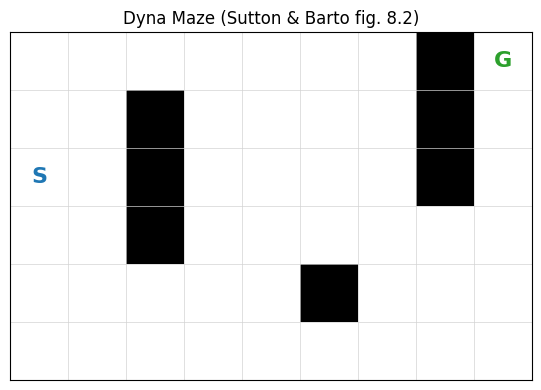

Etats : 54 (6x9), actions : 4
Depart (2, 0), but (0, 8), murs : 7


In [2]:
# Actions : 0=haut, 1=bas, 2=gauche, 3=droite
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
ACTION_NAMES = ["haut", "bas", "gauche", "droite"]


class Maze:
    """Labyrinthe deterministe episodique (Dyna Maze, Sutton & Barto fig. 8.2)."""

    def __init__(self, height=6, width=9, start=(2, 0), goal=(0, 8), obstacles=None):
        self.height = height
        self.width = width
        self.start = start
        self.goal = goal
        if obstacles is None:
            obstacles = {(1, 2), (2, 2), (3, 2), (4, 5), (0, 7), (1, 7), (2, 7)}
        self.obstacles = set(obstacles)
        self.n_states = height * width
        self.n_actions = len(ACTIONS)

    def idx(self, state):
        """Encode un etat (ligne, colonne) en entier pour indexer la Q-table."""
        return state[0] * self.width + state[1]

    def reset(self):
        return self.start

    def step(self, state, action):
        """Transition deterministe : (etat, action) -> (etat_suivant, recompense, terminal)."""
        dr, dc = ACTIONS[action]
        nr, nc = state[0] + dr, state[1] + dc
        if not (0 <= nr < self.height and 0 <= nc < self.width) or (nr, nc) in self.obstacles:
            nr, nc = state  # mur ou bord : on reste sur place
        next_state = (nr, nc)
        if next_state == self.goal:
            return next_state, 1.0, True
        return next_state, 0.0, False


def render_maze(maze, ax=None, title="Dyna Maze (Sutton & Barto fig. 8.2)"):
    """Affiche la grille : murs en noir, depart S, but G."""
    grid = np.zeros((maze.height, maze.width))
    for (r, c) in maze.obstacles:
        grid[r, c] = 1.0
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    ax.imshow(grid, cmap="gray_r", vmin=0, vmax=1)
    ax.text(maze.start[1], maze.start[0], "S", ha="center", va="center",
            fontsize=16, fontweight="bold", color="tab:blue")
    ax.text(maze.goal[1], maze.goal[0], "G", ha="center", va="center",
            fontsize=16, fontweight="bold", color="tab:green")
    ax.set_xticks(np.arange(-0.5, maze.width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, maze.height, 1), minor=True)
    ax.grid(which="minor", color="lightgray", linewidth=0.5)
    ax.tick_params(which="both", bottom=False, left=False,
                   labelbottom=False, labelleft=False)
    ax.set_title(title)
    return ax


maze = Maze()
render_maze(maze)
plt.tight_layout()
plt.show()

print(f"Etats : {maze.n_states} ({maze.height}x{maze.width}), actions : {maze.n_actions}")
print(f"Depart {maze.start}, but {maze.goal}, murs : {len(maze.obstacles)}")

La recompense n'arrive qu'au but : tant que l'agent n'a pas atteint `G` au moins une fois,
toutes ses estimations $Q(s,a)$ restent nulles et il erre au hasard. C'est precisement dans ce
regime de **recompense eparse** que la planification va briller : la *premiere* trajectoire
gagnante, une fois memorisee dans le modele, peut etre rejouee en boucle pour propager la valeur
tout le long du chemin — sans un seul pas reel supplementaire.

## 3. Baseline model-free : Q-Learning direct

Rappel du notebook 5 — la mise a jour Q-Learning sur une transition reelle $(s, a, r, s')$ :

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s,a) \right]$$

Nous mesurons la performance en **nombre de pas par episode** : plus l'agent apprend vite,
plus cette courbe chute rapidement vers l'optimum (14 pas).

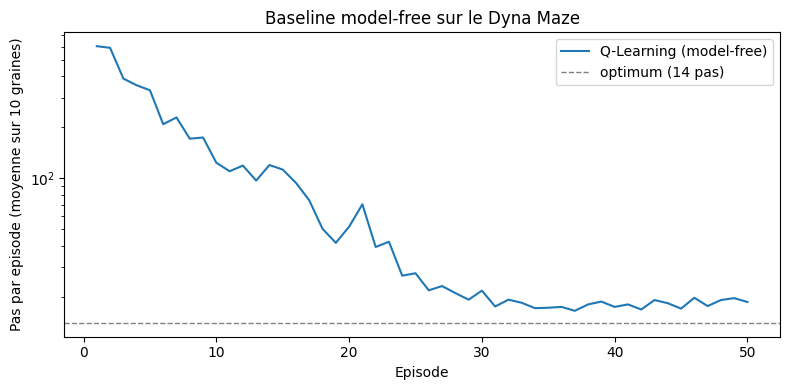

Pas au 1er episode  : 603
Pas au 10e episode  : 124
Pas au 50e episode  : 19


In [3]:
GAMMA = 0.95
ALPHA = 0.5      # env. deterministe : un taux d'apprentissage eleve est sans risque
EPSILON = 0.1
MAX_STEPS_EPISODE = 2000  # garde-fou contre les episodes infinis


def epsilon_greedy(Q, s_idx, n_actions, eps, rng):
    """Politique epsilon-greedy avec bris d'egalite aleatoire."""
    if rng.random() < eps:
        return int(rng.integers(n_actions))
    q_row = Q[s_idx]
    return int(rng.choice(np.flatnonzero(q_row == q_row.max())))


def q_learning(env, n_episodes=50, alpha=ALPHA, gamma=GAMMA, eps=EPSILON, seed=0):
    """Q-Learning tabulaire pur (model-free). Retourne les pas par episode et Q."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    steps_per_episode = []
    for _ in range(n_episodes):
        s = env.reset()
        for t in range(1, MAX_STEPS_EPISODE + 1):
            a = epsilon_greedy(Q, env.idx(s), env.n_actions, eps, rng)
            s2, r, done = env.step(s, a)
            target = r if done else r + gamma * Q[env.idx(s2)].max()
            Q[env.idx(s), a] += alpha * (target - Q[env.idx(s), a])
            s = s2
            if done:
                break
        steps_per_episode.append(t)
    return np.array(steps_per_episode), Q


# Moyenne sur 10 graines pour lisser la variance
N_RUNS, N_EPISODES = 10, 50
runs = np.array([q_learning(maze, N_EPISODES, seed=k)[0] for k in range(N_RUNS)])
mean_steps_qlearning = runs.mean(axis=0)

plt.figure(figsize=(8, 4))
plt.plot(range(1, N_EPISODES + 1), mean_steps_qlearning, label="Q-Learning (model-free)")
plt.axhline(14, color="gray", linestyle="--", linewidth=1, label="optimum (14 pas)")
plt.xlabel("Episode")
plt.ylabel("Pas par episode (moyenne sur 10 graines)")
plt.title("Baseline model-free sur le Dyna Maze")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pas au 1er episode  : {mean_steps_qlearning[0]:.0f}")
print(f"Pas au 10e episode  : {mean_steps_qlearning[9]:.0f}")
print(f"Pas au 50e episode  : {mean_steps_qlearning[-1]:.0f}")

Lecture de la courbe : le premier episode est une marche aleatoire (plusieurs centaines de pas),
puis la valeur se propage *d'un pas en arriere par episode* environ — chaque traversee reelle
n'ameliore qu'une petite partie du chemin. Il faut des dizaines d'episodes pour approcher les 14 pas
optimaux. **Toute l'information necessaire etait pourtant deja la** des la premiere arrivee au but :
le reste n'est que propagation, et la propagation n'a pas besoin d'experience reelle.
C'est exactement ce que la planification va exploiter.

## 4. Apprendre un modele du monde

Dans un environnement **deterministe**, le modele le plus simple est une table :
pour chaque paire $(s, a)$ deja essayee, on memorise le couple observe $(r, s')$.
Une seule observation suffit — le modele est alors *exact* sur tout ce qui a ete visite.

$$\hat{M}(s, a) = (r, s', \text{terminal})$$

Deux limites a garder en tete :

- **Couverture** : le modele ne sait rien des paires $(s,a)$ jamais essayees.
  La planification ne peut rejouer que du deja-vu.
- **Stochasticite** : si l'environnement est aleatoire, une table ne suffit plus — il faut estimer
  des distributions, par exemple par comptage de frequences $\hat{P}(s'|s,a)$, voire des lois
  a priori bayesiennes (pont direct avec la serie [Probas](../Probas/README.md)).

In [4]:
class DeterministicModel:
    """Modele tabulaire pour environnement deterministe.

    Memorise (s_idx, a) -> (r, s2_idx, done) et permet d'echantillonner
    uniformement une paire deja observee (planification Dyna).
    """

    def __init__(self):
        self.transitions = {}
        self._keys = []  # liste maintenue pour echantillonner en O(1)

    def update(self, s_idx, a, r, s2_idx, done):
        key = (s_idx, a)
        if key not in self.transitions:
            self._keys.append(key)
        self.transitions[key] = (r, s2_idx, done)

    def sample(self, rng):
        """Tire une paire (s, a) observee et retourne (s, a, r, s', done)."""
        s_idx, a = self._keys[int(rng.integers(len(self._keys)))]
        r, s2_idx, done = self.transitions[(s_idx, a)]
        return s_idx, a, r, s2_idx, done

    def __len__(self):
        return len(self.transitions)


# Demonstration : remplir le modele par une courte marche aleatoire
rng_demo = np.random.default_rng(SEED)
model_demo = DeterministicModel()
s = maze.reset()
for _ in range(200):
    a = int(rng_demo.integers(maze.n_actions))
    s2, r, done = maze.step(s, a)
    model_demo.update(maze.idx(s), a, r, maze.idx(s2), done)
    s = maze.reset() if done else s2

total_pairs = maze.n_states * maze.n_actions
print(f"Apres 200 pas aleatoires : {len(model_demo)} paires (s,a) memorisees "
      f"sur {total_pairs} possibles ({100 * len(model_demo) / total_pairs:.0f}%)")
s_idx, a, r, s2_idx, done = model_demo.sample(rng_demo)
print(f"Exemple de transition simulee : etat {s_idx}, action '{ACTION_NAMES[a]}' "
      f"-> recompense {r}, etat {s2_idx}, terminal={done}")

Apres 200 pas aleatoires : 93 paires (s,a) memorisees sur 216 possibles (43%)
Exemple de transition simulee : etat 39, action 'bas' -> recompense 0.0, etat 48, terminal=False


## 5. Dyna-Q : apprendre ET planifier

Dyna-Q ajoute une boucle de planification au Q-Learning. A chaque pas **reel**, l'agent effectue
en plus $n$ mises a jour sur des transitions **simulees** tirees du modele :

```
Boucler a chaque pas de temps :
  (a) s    <- etat courant
  (b) a    <- epsilon-greedy(s, Q)
  (c) r,s' <- ENVIRONNEMENT.step(s, a)                 # experience reelle
  (d) Q(s,a) <- Q(s,a) + alpha [r + gamma max_a' Q(s',a') - Q(s,a)]
  (e) Modele(s,a) <- (r, s')                           # apprentissage du modele
  (f) Repeter n fois :                                 # planification
        (s~, a~)  <- paire deja observee, au hasard
        (r~, s~') <- Modele(s~, a~)
        Q(s~,a~) <- Q(s~,a~) + alpha [r~ + gamma max_a' Q(s~',a~') - Q(s~,a~)]
```

Les etapes (d) et (f) utilisent **exactement la meme regle de mise a jour** — la planification
est du Q-Learning sur souvenirs. Avec $n = 0$, on retrouve le Q-Learning pur.

> **Remarque** : ce mecanisme rappelle l'experience replay du DQN (notebook 3 et 6). La filiation
> est reelle, avec une nuance : le replay buffer rejoue des transitions *stockees telles quelles*,
> tandis qu'un modele peut en principe *generer* des transitions jamais vecues (etats recombines,
> predictions). En tabulaire deterministe, les deux coincident presque.

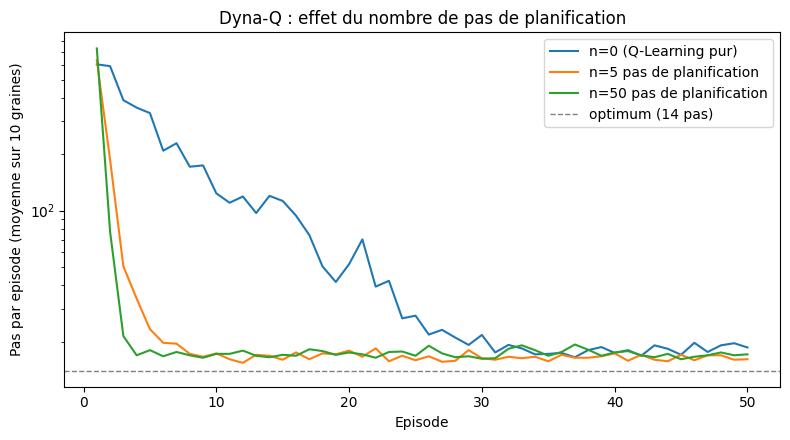

Premier episode ou la moyenne passe sous 25 pas :
  n= 0 : episode 26
  n= 5 : episode 5
  n=50 : episode 3


In [5]:
def dyna_q(env, n_episodes=50, n_planning=5, alpha=ALPHA, gamma=GAMMA,
           eps=EPSILON, seed=0):
    """Dyna-Q tabulaire : Q-Learning + modele + n_planning pas simules par pas reel."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    model = DeterministicModel()
    steps_per_episode = []
    for _ in range(n_episodes):
        s = env.reset()
        for t in range(1, MAX_STEPS_EPISODE + 1):
            s_idx = env.idx(s)
            a = epsilon_greedy(Q, s_idx, env.n_actions, eps, rng)
            s2, r, done = env.step(s, a)
            s2_idx = env.idx(s2)
            # (d) apprentissage direct
            target = r if done else r + gamma * Q[s2_idx].max()
            Q[s_idx, a] += alpha * (target - Q[s_idx, a])
            # (e) apprentissage du modele
            model.update(s_idx, a, r, s2_idx, done)
            # (f) planification : n pas simules
            for _ in range(n_planning):
                ps, pa, pr, ps2, pdone = model.sample(rng)
                ptarget = pr if pdone else pr + gamma * Q[ps2].max()
                Q[ps, pa] += alpha * (ptarget - Q[ps, pa])
            s = s2
            if done:
                break
        steps_per_episode.append(t)
    return np.array(steps_per_episode), Q, model


# Comparaison n_planning = 0 / 5 / 50 (moyenne sur 10 graines)
PLANNING_LEVELS = [0, 5, 50]
results = {}
for n_plan in PLANNING_LEVELS:
    runs = np.array([dyna_q(maze, N_EPISODES, n_planning=n_plan, seed=k)[0]
                     for k in range(N_RUNS)])
    results[n_plan] = runs.mean(axis=0)

plt.figure(figsize=(8, 4.5))
for n_plan, curve in results.items():
    label = "n=0 (Q-Learning pur)" if n_plan == 0 else f"n={n_plan} pas de planification"
    plt.plot(range(1, N_EPISODES + 1), curve, label=label)
plt.axhline(14, color="gray", linestyle="--", linewidth=1, label="optimum (14 pas)")
plt.xlabel("Episode")
plt.ylabel("Pas par episode (moyenne sur 10 graines)")
plt.title("Dyna-Q : effet du nombre de pas de planification")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

print("Premier episode ou la moyenne passe sous 25 pas :")
for n_plan, curve in results.items():
    below = np.argmax(curve < 25) + 1 if (curve < 25).any() else None
    print(f"  n={n_plan:>2} : episode {below}")

Le resultat reproduit la figure 8.3 de Sutton & Barto : a **experience reelle egale**, l'agent qui
planifie 50 pas par pas reel atteint un comportement quasi optimal en 3-4 episodes, la ou le
Q-Learning pur en demande plus de vingt. Le premier episode est identique pour tous (modele vide,
marche aleatoire) ; tout le gain se joue ensuite, quand chaque pas reel est demultiplie par la relecture
du modele.

Le prix paye n'est pas en echantillons mais en **calcul** : $n = 50$ multiplie par ~50 le nombre de
mises a jour par pas reel. Ce compromis "calcul contre experience" est au coeur du model-based RL
moderne : la ou l'experience est chere (robotique, medecine, finance), bruler du CPU/GPU pour
economiser des interactions reelles est presque toujours rentable.

## 6. Quand le modele se trompe : Blocking Maze et Dyna-Q+

La force de Dyna-Q — rejouer le passe memorise — devient une faiblesse si **l'environnement change** :
le modele continue de planifier sur un monde qui n'existe plus.

Experience du **Blocking Maze** (Sutton & Barto, fig. 8.4) : pendant les 1000 premiers pas, le seul
passage est a **droite** ; au pas 1000, le mur se decale et le passage de droite se ferme tandis qu'un
passage s'ouvre a **gauche**.

```
Avant (pas 0-999)            Apres (pas 1000+)
. . . . . . . . G            . . . . . . . . G
. . . . . . . . .            . . . . . . . . .
. . . . . . . . .            . . . . . . . . .
# # # # # # # # .            . # # # # # # # #
. . . . . . . . .            . . . . . . . . .
. . . S . . . . .            . . . S . . . . .
```

**Dyna-Q+** (variante exploratoire de Dyna-Q) ajoute deux ingredients pour rester curieux :

1. Un **bonus d'exploration** dans la planification : si la paire $(s,a)$ n'a pas ete essayee
   *reellement* depuis $\tau(s,a)$ pas, la planification utilise la recompense augmentee

   $$r + \kappa \sqrt{\tau(s,a)}$$

   Les transitions anciennes paraissent ainsi de plus en plus attrayantes : l'agent retourne
   periodiquement verifier si le monde a change.
2. La planification considere aussi les **actions jamais essayees** depuis un etat visite
   (modelisees par defaut comme "rester sur place, recompense 0"), pour que le bonus puisse
   les rendre attractives.

Nous mesurons la **recompense cumulee** : la pente de la courbe indique a quelle frequence l'agent
atteint le but.

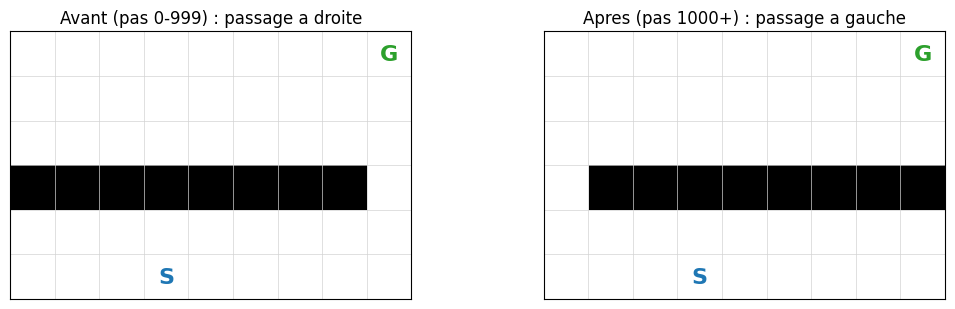

In [6]:
class ChangingMaze(Maze):
    """Labyrinthe dont les murs changent a un instant donne (Blocking/Shortcut Maze)."""

    def __init__(self, obstacles_before, obstacles_after, switch_time,
                 start=(5, 3), goal=(0, 8), height=6, width=9):
        super().__init__(height=height, width=width, start=start, goal=goal,
                         obstacles=obstacles_before)
        self.obstacles_before = set(obstacles_before)
        self.obstacles_after = set(obstacles_after)
        self.switch_time = switch_time

    def step(self, state, action, t=0):
        """Comme Maze.step, mais la carte depend du pas de temps global t."""
        self.obstacles = self.obstacles_before if t < self.switch_time else self.obstacles_after
        return super().step(state, action)


# Blocking Maze : passage a droite, puis passage a gauche uniquement
wall_before = {(3, c) for c in range(0, 8)}   # ouverture en (3, 8)
wall_after = {(3, c) for c in range(1, 9)}    # ouverture en (3, 0)
SWITCH_T, TOTAL_T = 1000, 3000
blocking_maze = ChangingMaze(wall_before, wall_after, switch_time=SWITCH_T)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
blocking_maze.obstacles = wall_before
render_maze(blocking_maze, ax=axes[0], title=f"Avant (pas 0-{SWITCH_T - 1}) : passage a droite")
blocking_maze.obstacles = wall_after
render_maze(blocking_maze, ax=axes[1], title=f"Apres (pas {SWITCH_T}+) : passage a gauche")
plt.tight_layout()
plt.show()

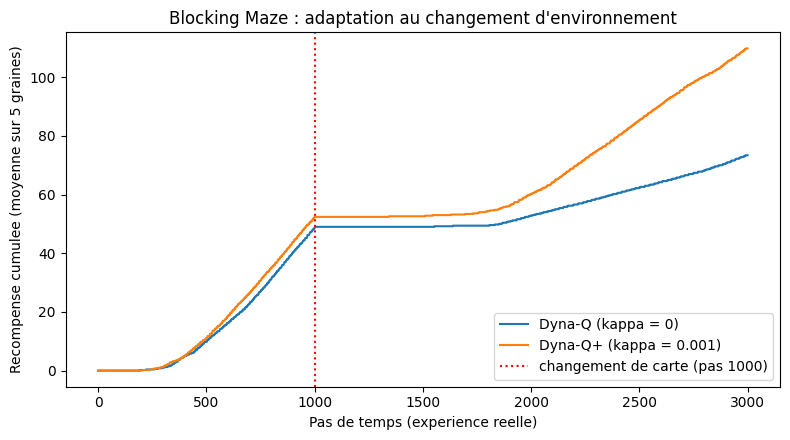

Recompense cumulee finale — Dyna-Q : 73.4 | Dyna-Q+ : 109.8


In [7]:
def dyna_q_steps(env, total_steps, n_planning=10, kappa=0.0,
                 alpha=ALPHA, gamma=GAMMA, eps=EPSILON, seed=0):
    """Dyna-Q / Dyna-Q+ sur un budget de pas REELS (environnement changeant).

    kappa = 0   : Dyna-Q standard.
    kappa > 0   : Dyna-Q+ (bonus kappa*sqrt(tau) en planification + actions jamais essayees).
    Retourne la recompense cumulee a chaque pas.
    """
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    model = DeterministicModel()
    tau = np.zeros((env.n_states, env.n_actions))  # anciennete de chaque paire (s,a)
    cumulative = np.zeros(total_steps)
    total_reward = 0.0
    s = env.reset()
    for t in range(total_steps):
        s_idx = env.idx(s)
        a = epsilon_greedy(Q, s_idx, env.n_actions, eps, rng)
        s2, r, done = env.step(s, a, t=t)
        s2_idx = env.idx(s2)
        # apprentissage direct
        target = r if done else r + gamma * Q[s2_idx].max()
        Q[s_idx, a] += alpha * (target - Q[s_idx, a])
        # anciennete : tout vieillit d'un pas, la paire visitee rajeunit
        tau += 1.0
        tau[s_idx, a] = 0.0
        # apprentissage du modele
        model.update(s_idx, a, r, s2_idx, done)
        if kappa > 0:
            # Dyna-Q+ : les actions jamais essayees depuis un etat visite entrent
            # au modele comme (recompense 0, rester sur place) pour etre planifiables
            for a_untried in range(env.n_actions):
                if (s_idx, a_untried) not in model.transitions:
                    model.update(s_idx, a_untried, 0.0, s_idx, False)
        # planification
        for _ in range(n_planning):
            ps, pa, pr, ps2, pdone = model.sample(rng)
            bonus = kappa * np.sqrt(tau[ps, pa]) if kappa > 0 else 0.0
            ptarget = pr + bonus if pdone else pr + bonus + gamma * Q[ps2].max()
            Q[ps, pa] += alpha * (ptarget - Q[ps, pa])
        total_reward += r
        cumulative[t] = total_reward
        s = env.reset() if done else s2
    return cumulative


def run_blocking(kappa, n_seeds=5):
    curves = []
    for k in range(n_seeds):
        env = ChangingMaze(wall_before, wall_after, switch_time=SWITCH_T)
        curves.append(dyna_q_steps(env, TOTAL_T, n_planning=10, kappa=kappa, seed=k))
    return np.mean(curves, axis=0)


cum_dyna = run_blocking(kappa=0.0)
cum_dyna_plus = run_blocking(kappa=1e-3)

plt.figure(figsize=(8, 4.5))
plt.plot(cum_dyna, label="Dyna-Q (kappa = 0)")
plt.plot(cum_dyna_plus, label="Dyna-Q+ (kappa = 0.001)")
plt.axvline(SWITCH_T, color="red", linestyle=":", linewidth=1.5,
            label=f"changement de carte (pas {SWITCH_T})")
plt.xlabel("Pas de temps (experience reelle)")
plt.ylabel("Recompense cumulee (moyenne sur 5 graines)")
plt.title("Blocking Maze : adaptation au changement d'environnement")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Recompense cumulee finale — Dyna-Q : {cum_dyna[-1]:.1f} | "
      f"Dyna-Q+ : {cum_dyna_plus[-1]:.1f}")

Les deux courbes deviennent plates juste apres le pas 1000 : l'ancien chemin est mure, et les agents
persistent un moment a le suivre — leur modele (et leur $Q$) decrit un monde perime. La difference
se joue sur la **vitesse de re-decouverte** : grace a son bonus $\kappa\sqrt{\tau}$, Dyna-Q+
re-essaie systematiquement les zones non visitees recemment, retrouve le nouveau passage a gauche
plus tot, et sa pente repart plus vite. Dyna-Q standard finit aussi par s'adapter, mais uniquement
pousse par le hasard de l'$\varepsilon$-greedy.

Le bonus a un cout : en regime stationnaire, Dyna-Q+ "gaspille" des pas a re-verifier des couloirs
qui n'ont pas change. C'est le dilemme exploration/exploitation (notebook 4) transpose au
**non-stationnaire** — et l'exercice 3 vous fera mesurer ce que coute un $\kappa$ mal regle. Un ordre de grandeur de trop suffit : a $\kappa = 5	imes 10^{-3}$, le bonus amplifie par le bootstrap ($\gamma \max_a Q$) depasse la valeur reelle du but et la recompense cumulee s'effondre.
L'exercice 1 (Shortcut Maze) montre un cas plus frappant : quand le changement *ouvre un raccourci*
au lieu de fermer un passage, Dyna-Q standard ne le decouvre **jamais**.

## 7. Planification au moment de la decision : des rollouts a MCTS

Dyna planifie **en tache de fond** (background planning) : les mises a jour simulees ameliorent la
table $Q$ globale, sans privilegier l'etat courant. L'alternative est la **planification au moment
de la decision** (decision-time planning) : face a l'etat $s_t$, derouler le modele *vers l'avant*
pour evaluer les actions candidates, choisir, agir — puis tout jeter et recommencer.

La forme la plus simple est le **rollout** : pour chaque action candidate $a$, simuler quelques
centaines de trajectoires (politique aleatoire) partant de $(s_t, a)$ et moyenner les retours.

**Monte-Carlo Tree Search (MCTS)** rend ce principe efficace en concentrant la simulation sur les
branches prometteuses, via quatre phases repetees : **selection** (descendre l'arbre en arbitrant
exploration/exploitation, typiquement avec UCB — revoir le notebook 4), **expansion** (ajouter une
feuille), **simulation** (rollout), **retropropagation** (remonter les valeurs). C'est le moteur
d'**AlphaGo/AlphaZero** (modele = regles du jeu, parfaites) et de **MuZero** (modele *appris*,
comme Dyna — la boucle est bouclee).

In [8]:
def rollout_action_values(env, state, n_rollouts=300, depth=60, gamma=GAMMA, seed=0):
    """Estime Q(state, a) pour chaque action par rollouts aleatoires du modele.

    Ici le 'modele' est l'environnement lui-meme (modele parfait, comme les regles
    d'un jeu pour AlphaZero) : Maze.step est une fonction pure sans etat cache.
    """
    rng = np.random.default_rng(seed)
    estimates = np.zeros(env.n_actions)
    for a in range(env.n_actions):
        returns = []
        for _ in range(n_rollouts):
            s, (g, G) = state, (1.0, 0.0)
            s, r, done = env.step(s, a)
            G += g * r
            d = 0
            while not done and d < depth:
                g *= gamma
                s, r, done = env.step(s, int(rng.integers(env.n_actions)))
                G += g * r
                d += 1
            returns.append(G)
        estimates[a] = np.mean(returns)
    return estimates


# Planification depuis l'etat (3, 8) : juste sous le couloir menant au but (0, 8)
probe_state = (3, 8)
estimates = rollout_action_values(maze, probe_state, seed=SEED)

print(f"Valeurs estimees par rollouts depuis l'etat {probe_state} :")
for name, value in sorted(zip(ACTION_NAMES, estimates), key=lambda x: -x[1]):
    print(f"  {name:<8} : {value:.3f}")
print(f"\nMeilleure action : '{ACTION_NAMES[int(np.argmax(estimates))]}' "
      "(remonter le couloir vers G, comme attendu)")

Valeurs estimees par rollouts depuis l'etat (3, 8) :
  haut     : 0.356
  droite   : 0.184
  bas      : 0.101
  gauche   : 0.080

Meilleure action : 'haut' (remonter le couloir vers G, comme attendu)


Les rollouts identifient la bonne action sans aucune table $Q$ : toute l'intelligence vient de la
simulation vers l'avant. Mais la version naive est **myope et couteuse** : loin du but, presque tous
les rollouts aleatoires echouent (recompense eparse) et les estimations s'ecrasent vers zero ; et il
faut re-simuler a chaque pas. MCTS corrige les deux defauts en construisant un arbre asymetrique
guide par UCB — pour une implementation complete sur des jeux a deux joueurs, voir
[GameTheory-17-MultiAgent-RL](../GameTheory/GameTheory-17-MultiAgent-RL.ipynb) et les notebooks
OpenSpiel de la serie [GameTheory](../GameTheory/README.md).

## 8. Exercices

Les trois exercices reutilisent les briques construites plus haut (`ChangingMaze`, `dyna_q_steps`,
`DeterministicModel`). Completez les cellules de code : elles s'executent sans erreur en l'etat
(stubs), a vous de les remplir.

### Exercice 1 — Shortcut Maze : decouvrir un raccourci

Le Blocking Maze fermait un passage ; le **Shortcut Maze** (Sutton & Barto, fig. 8.5) en *ouvre* un :

```
Avant (pas 0-2999)           Apres (pas 3000+)
. . . . . . . . G            . . . . . . . . G
. . . . . . . . .            . . . . . . . . .
. . . . . . . . .            . . . . . . . . .
. # # # # # # # #            . # # # # # # # .   <- raccourci ouvert a droite
. . . . . . . . .            . . . . . . . . .
. . . S . . . . .            . . . S . . . . .
```

L'ancien chemin (par la gauche) **reste valide** : rien ne force l'agent a explorer. Un agent
purement glouton n'a aucune raison de remarquer le raccourci... sauf s'il est curieux.

**Travail demande** :

1. Construire le `ChangingMaze` correspondant (murs avant/apres, `switch_time=3000`) ;
2. Lancer `dyna_q_steps` sur 6000 pas avec `kappa=0` (Dyna-Q) et `kappa=1e-3` (Dyna-Q+),
   moyenne sur 5 graines ;
3. Tracer les recompenses cumulees et comparer les pentes apres le pas 3000.

**Resultat attendu** : Dyna-Q garde la meme pente (il ne decouvre jamais le raccourci) ;
la pente de Dyna-Q+ augmente apres l'ouverture.

In [9]:
# Exercice 1 — Shortcut Maze
# Etape 1 : definir les murs avant/apres (s'inspirer de wall_before / wall_after)
#           Avant : mur ligne 3, colonnes 1 a 8 (passage a gauche seulement)
#           Apres : mur ligne 3, colonnes 1 a 7 (passages a gauche ET a droite)
# Etape 2 : creer le ChangingMaze avec switch_time=3000
# Etape 3 : lancer dyna_q_steps(env, 6000, n_planning=10, kappa=...) pour kappa=0 et kappa=1e-3
#           (moyenne sur 5 graines, comme run_blocking)
# Etape 4 : tracer les deux courbes de recompense cumulee + axvline au pas 3000

shortcut_wall_before = None  # TODO etudiant
shortcut_wall_after = None   # TODO etudiant
shortcut_env = None          # TODO etudiant

# Indice : la pente apres 3000 est ~ (recompense finale - recompense a 3000) / 3000.
# Calculer cette pente pour les deux agents rend la comparaison quantitative.

print("Exercice 1 a completer")

Exercice 1 a completer


### Exercice 2 — Prioritized Sweeping : planifier la ou ca compte

Dyna-Q echantillonne ses transitions simulees **uniformement** : la plupart des mises a jour ne
changent rien (la valeur en amont n'a pas bouge). Le **prioritized sweeping** (Moore & Atkeson, 1993)
planifie en priorite la ou la surprise est grande :

1. A chaque transition (reelle ou simulee), calculer l'erreur $|\delta| = |r + \gamma \max_{a'} Q(s',a') - Q(s,a)|$ ;
2. Si $|\delta| > \theta$, inserer $(s,a)$ dans une **file de priorite** avec priorite $|\delta|$ ;
3. A chaque pas de planification, traiter la paire la plus prioritaire, puis examiner tous les
   **predecesseurs** connus de $s$ (les paires $(\bar{s},\bar{a})$ telles que le modele donne
   $\bar{s} \xrightarrow{\bar{a}} s$) et les inserer a leur tour si leur erreur depasse $\theta$.

La valeur se propage ainsi **a rebours** depuis le but, en cascade ciblee.

**Travail demande** : completer `prioritized_sweeping` ci-dessous (squelette fourni), puis comparer
le nombre d'episodes necessaires pour atteindre 25 pas/episode face a Dyna-Q ($n=5$) sur le Dyna Maze.

**Indices** : `heapq` avec priorites negatives (file max), un `dict` `predecessors[s2] -> set de (s, a)`
rempli au fil des transitions reelles, et $\theta \approx 10^{-4}$.

In [10]:
import heapq


def prioritized_sweeping(env, n_episodes=50, n_planning=5, alpha=ALPHA, gamma=GAMMA,
                         eps=EPSILON, theta=1e-4, seed=0):
    """Squelette de prioritized sweeping — a completer (exercice 2)."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    model = DeterministicModel()
    predecessors = defaultdict(set)  # s2_idx -> {(s_idx, a), ...}
    pqueue = []                      # tas de (-priorite, s_idx, a)
    steps_per_episode = []

    for _ in range(n_episodes):
        s = env.reset()
        for t in range(1, MAX_STEPS_EPISODE + 1):
            s_idx = env.idx(s)
            a = epsilon_greedy(Q, s_idx, env.n_actions, eps, rng)
            s2, r, done = env.step(s, a)
            s2_idx = env.idx(s2)
            model.update(s_idx, a, r, s2_idx, done)
            predecessors[s2_idx].add((s_idx, a))

            # TODO etudiant — Etape 1 : calculer |delta| pour (s_idx, a)
            #   et inserer dans pqueue si |delta| > theta
            #   (heapq.heappush(pqueue, (-abs(delta), s_idx, a)))

            # TODO etudiant — Etape 2 : boucle de planification (n_planning iterations) :
            #   - depiler la paire la plus prioritaire (heapq.heappop)
            #   - appliquer la mise a jour Q-Learning via le modele
            #   - pour chaque predecesseur (ps, pa) de l'etat traite :
            #       calculer son |delta| et l'inserer si > theta

            s = s2
            if done:
                break
        steps_per_episode.append(t)
    return np.array(steps_per_episode), Q


# TODO etudiant — Etape 3 : comparer prioritized_sweeping et dyna_q (n_planning=5)
#   sur 10 graines : tracer les deux courbes de pas par episode.
print("Exercice 2 a completer")

Exercice 2 a completer


### Exercice 3 — Sensibilite du bonus d'exploration $\kappa$

Le bonus $\kappa\sqrt{\tau}$ de Dyna-Q+ arbitre entre re-exploration et exploitation.
Trop faible, l'agent ne re-decouvre rien ; trop fort, il passe son temps a re-verifier des couloirs
inchanges au lieu d'aller au but.

**Travail demande** :

1. Sur le **Blocking Maze** (3000 pas, changement a 1000), faire varier
   $\kappa \in \{0,\ 10^{-4},\ 10^{-3},\ 5 \times 10^{-3},\ 10^{-2},\ 10^{-1}\}$ ;
2. Pour chaque valeur, relever la **recompense cumulee finale** (moyenne sur 5 graines) ;
3. Tracer recompense finale vs $\kappa$ (echelle log en x, traiter $\kappa = 0$ a part) ;
4. Repondre : que se passe-t-il pour $\kappa = 0.1$, et pourquoi ?

**Indice** : avec un bonus enorme, la valeur planifiee d'une paire ancienne depasse la valeur
reelle du but ($+1$) — l'agent prefere "visiter du vieux" plutot que de gagner.

In [11]:
# Exercice 3 — balayage de kappa sur le Blocking Maze
kappas = [0.0, 1e-4, 1e-3, 5e-3, 1e-2, 1e-1]

final_rewards = None  # TODO etudiant : liste des recompenses cumulees finales,
                      # une par valeur de kappa (reutiliser run_blocking)

# TODO etudiant : tracer final_rewards vs kappas (plt.semilogx sur kappas[1:],
# point separe pour kappa=0) et commenter le kappa optimal.

print("Exercice 3 a completer")

Exercice 3 a completer


## Conclusion et passerelles

### Ce qu'il faut retenir

| Concept | Idee cle |
|---------|----------|
| Modele du monde | Predire $(r, s')$ a partir de $(s, a)$ ; appris par memorisation (deterministe) ou estimation (stochastique) |
| Dyna-Q | Q-Learning + $n$ mises a jour simulees par pas reel ; meme regle de mise a jour, experience gratuite |
| Sample efficiency | A experience reelle egale, la planification accelere drastiquement la convergence (calcul contre echantillons) |
| Modele perime | Un environnement qui change rend la planification nuisible ; Dyna-Q+ re-explore via le bonus $\kappa\sqrt{\tau}$ |
| Decision-time planning | Rollouts et MCTS simulent vers l'avant depuis l'etat courant ; AlphaZero (modele parfait), MuZero (modele appris) |

### Passerelles vers les autres series

- **[GameTheory](../GameTheory/README.md)** : MCTS est au coeur d'AlphaZero ; le notebook
  [GameTheory-17-MultiAgent-RL](../GameTheory/GameTheory-17-MultiAgent-RL.ipynb) applique
  ces idees aux jeux a deux joueurs via OpenSpiel.
- **[Search](../Search/README.md)** : la planification par modele EST de la recherche dans un espace
  d'etats — value iteration (notebook 5) et A* sont deux reponses au meme probleme.
- **[Probas](../Probas/README.md)** : quand l'etat n'est pas observable, le modele s'etend en
  **POMDP** (notebooks 17-20, theorie de la decision bayesienne) ; l'estimation d'un modele
  stochastique par comptage est une inference bayesienne deguisee.
- **[QuantConnect](../QuantConnect/README.md)** : un backtest est un *modele de marche* sur lequel on
  planifie des strategies — avec exactement le danger vu ici : le marche reel change (regime shifts),
  et un modele perime (overfitting au passe) detruit la performance
  ([QC-Py-32-RL-DQN-Trading](../QuantConnect/Python/QC-Py-32-RL-DQN-Trading.ipynb)).
- **[GenAI](../GenAI/README.md)** : les *world models* des agents modernes (simulateurs appris par
  reseaux de neurones) prolongent Dyna avec des modeles profonds ; le post-training RLHF
  ([FT-04-RLHF-DPO](../GenAI/FineTuning/FT-04-RLHF-DPO.ipynb)) optimise contre un *modele de
  recompense* appris — avec le meme risque de sur-optimisation d'un modele faux (reward hacking).

### References

- Sutton & Barto, *Reinforcement Learning: An Introduction* (2e ed.), chapitre 8
- Sutton (1990), *Integrated Architectures for Learning, Planning, and Reacting* (Dyna)
- Moore & Atkeson (1993), *Prioritized Sweeping*
- Silver et al. (2018), *AlphaZero* ; Schrittwieser et al. (2020), *MuZero*